In [116]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("CarPrice_Assignment.csv")
data = df.copy()

In [11]:
print(data.isnull().sum())

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [13]:
data['CarBrand'] = data['CarName'].apply(lambda x: x.split()[0].lower())

In [15]:
data['CarBrand']

0      alfa-romero
1      alfa-romero
2      alfa-romero
3             audi
4             audi
          ...     
200          volvo
201          volvo
202          volvo
203          volvo
204          volvo
Name: CarBrand, Length: 205, dtype: object

In [17]:
data.drop('CarName', axis=1, inplace=True)

In [19]:
brand_corrections = {
    'maxda': 'mazda', 'porcshce': 'porsche', 'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen', 'alfa-romero': 'alfa-romeo'
}
data['CarBrand'] = data['CarBrand'].replace(brand_corrections)

In [21]:
categorical_cols = data.select_dtypes(include='object').columns
data[categorical_cols] = data[categorical_cols].apply(lambda x: x.str.lower())

In [23]:
num_cols_to_fix = ['horsepower', 'peakrpm', 'citympg', 'highwaympg']
data[num_cols_to_fix] = data[num_cols_to_fix].apply(pd.to_numeric)

In [27]:
print(data.isnull().sum())

car_ID              0
symboling           0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
CarBrand            0
dtype: int64


### Linear Regression

In [32]:
X = data.drop('price', axis=1)
y = data['price']

In [34]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)
X_encoded = preprocessor.fit_transform(X)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [42]:
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.3f}")

Root Mean Squared Error (RMSE): 3039.20
R-squared (R²): 0.883


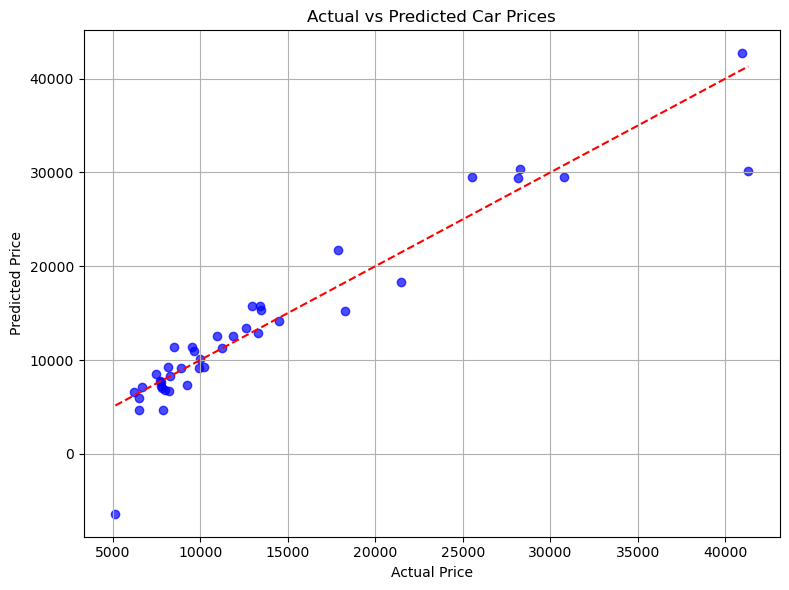

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

### Decision Tree Regressor

In [51]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [53]:
y_pred = tree_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [55]:
print(f"Decision Tree RMSE: {rmse:.2f}")
print(f"Decision Tree R²: {r2:.3f}")

Decision Tree RMSE: 2797.74
Decision Tree R²: 0.901


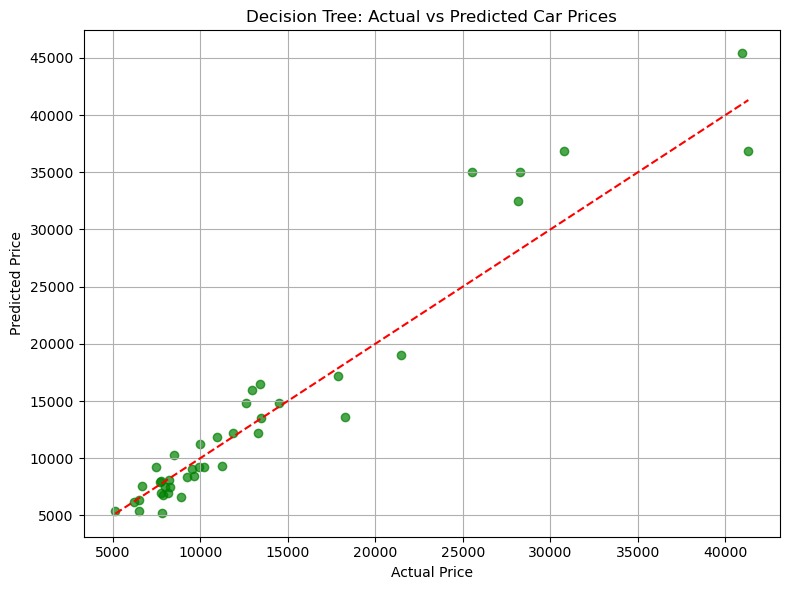

In [57]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Decision Tree: Actual vs Predicted Car Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

### Random Forest Regressor

In [62]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [64]:
y_pred = rf_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [66]:
print(f"Random Forest RMSE: {rmse:.2f}")
print(f"Random Forest R²: {r2:.3f}")

Random Forest RMSE: 1883.75
Random Forest R²: 0.955


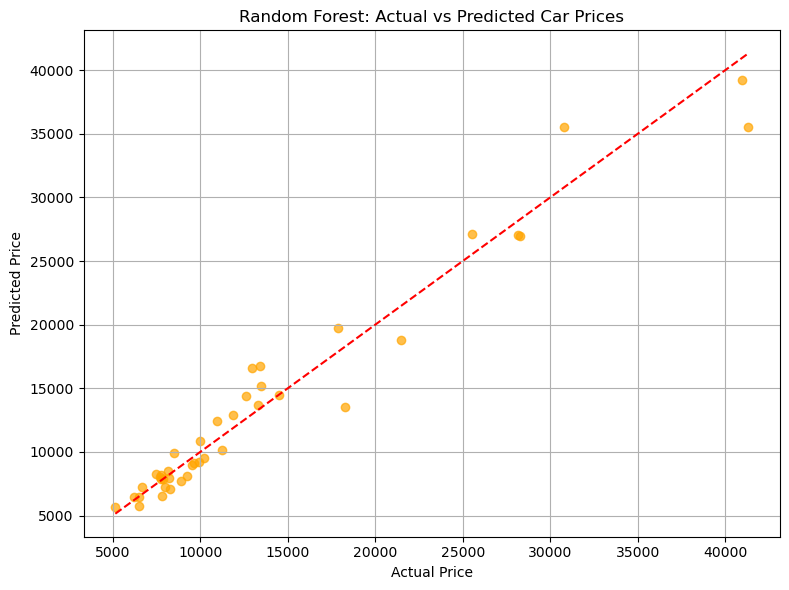

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='orange', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted Car Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

###  Gradient Boosting Regressor 

In [74]:
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [76]:
y_pred = gbr_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [78]:
print(f"Gradient Boosting RMSE: {rmse:.2f}")
print(f"Gradient Boosting R²: {r2:.3f}")

Gradient Boosting RMSE: 2361.15
Gradient Boosting R²: 0.929


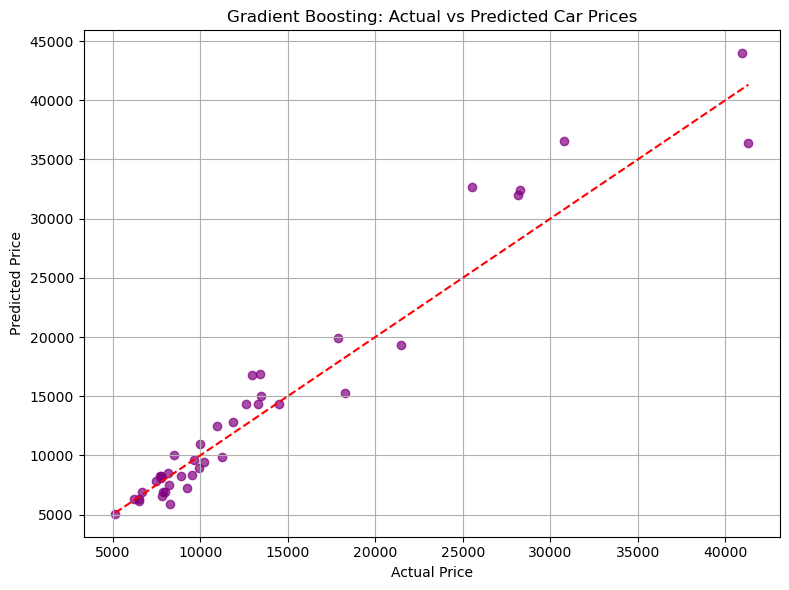

In [80]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='purple', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Gradient Boosting: Actual vs Predicted Car Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

###  Support Vector Regressor

In [87]:
svr_model = SVR(kernel='rbf', C=100, epsilon=1.0)
svr_model.fit(X_train, y_train)

SVR(C=100, epsilon=1.0)

In [89]:
y_pred = svr_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [93]:
print(f"Support Vector Regression RMSE: {rmse:.2f}")
print(f"Support Vector Regression R²: {r2:.3f}")

Support Vector Regression RMSE: 9146.36
Support Vector Regression R²: -0.060


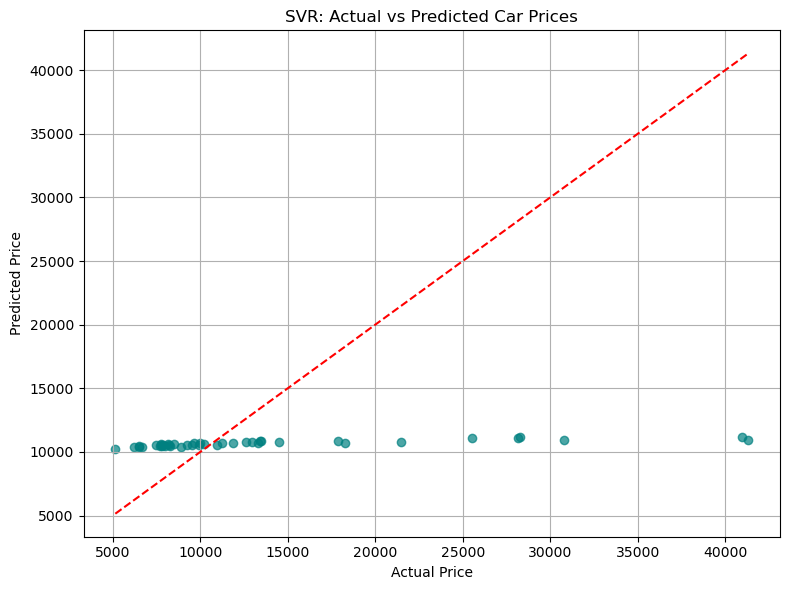

In [95]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVR: Actual vs Predicted Car Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

### 3. Comparison of all models
Random Forest Regressor performs best overall with the highest R² (~0.958) and lowest error values.

Support Vector Regressor (SVR) performs poorly in this case. It is likely due to sensitivity to unscaled high-dimensional categorical data or inadequate kernel tuning.

Gradient Boosting Regressor performs very well too, second to Random Forest.

Linear Regression and Decision Tree provide reasonably good performance but are outperformed by ensemble models.

### Best Performing Model?
The best performing model is Random Forest Regressor.

R² =0.958

With an R² of 0.958, Random Forest explains 95.8% of the variation in car prices — more than any other model tested.

MSE=3.33 × 10⁶

MAE=1287.06

It yields the lowest MSE and MAE, indicating smaller deviations from actual car prices and more reliable predictions.

The model seamlessly works with one-hot encoded features from the dataset, including car brands, fuel type, etc.
Random Forests are ensemble-based models that capture nonlinear relationships and interactions between features — essential for real-world car pricing where design, brand, and specs interact in complex ways.

### 4. Feature Selection
engine size – Strongest predictor of price

curb weight – Heavier cars tend to cost more

highwaympg – Fuel efficiency influences value

horsepower – Higher power often correlates with higher price

carwidth – Suggests size or luxury of the vehicle

CarBrand_bmw – Brand effect: BMW cars tend to be priced higher

car length, wheel base – Dimensions indicating vehicle size/class

citympg, peakrpm – Performance and efficiency indicators

bore ratio, stroke, compressionratio – Engine geometry parameters

car height, fuel system_mpfi – Slight influence on performance and fuel delivery